In [7]:
!apt-get install -y graphviz -q
!pip install graphviz -q

Reading package lists...
Building dependency tree...
Reading state information...
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


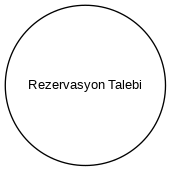

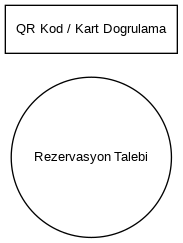

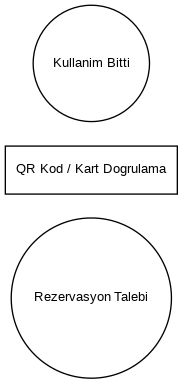

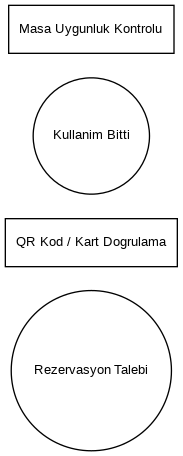

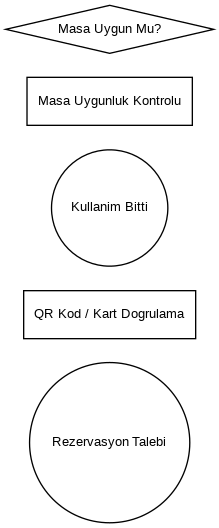

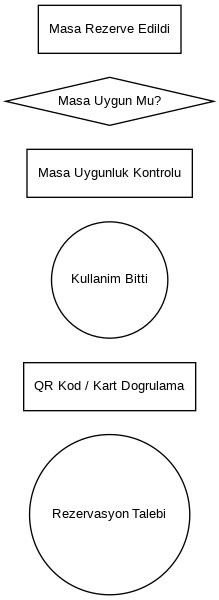

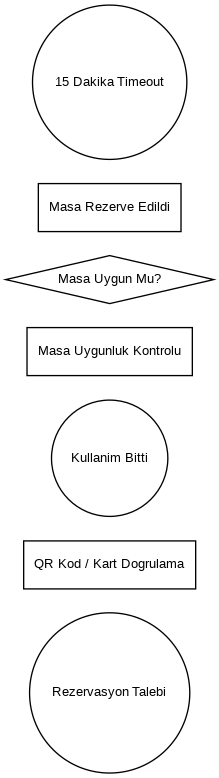

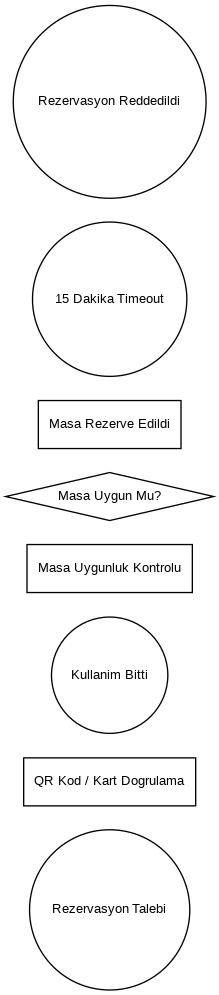

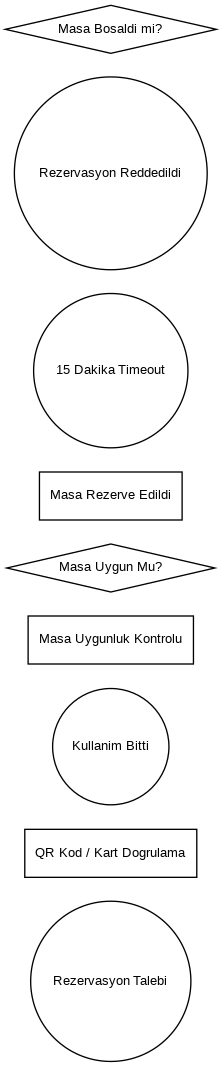

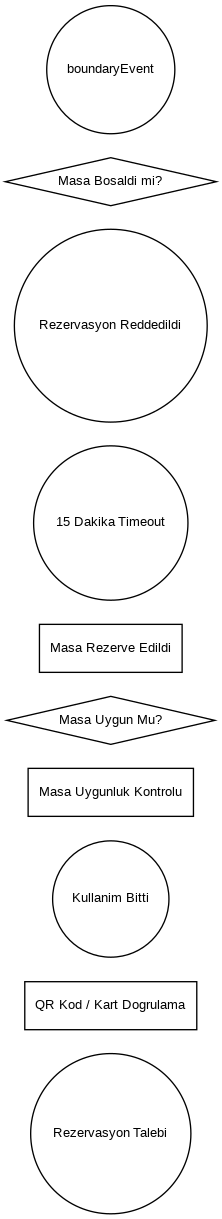

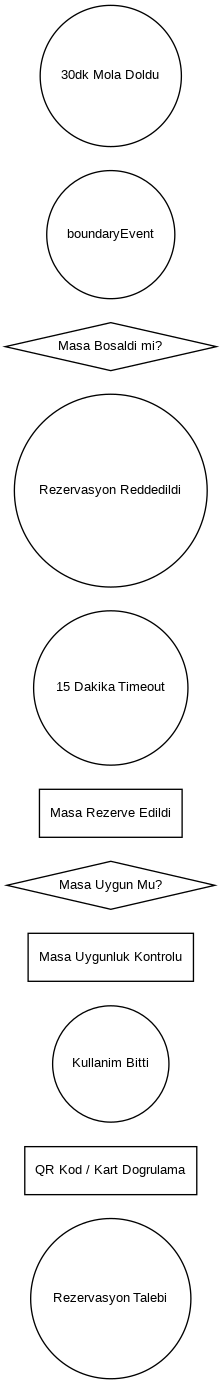

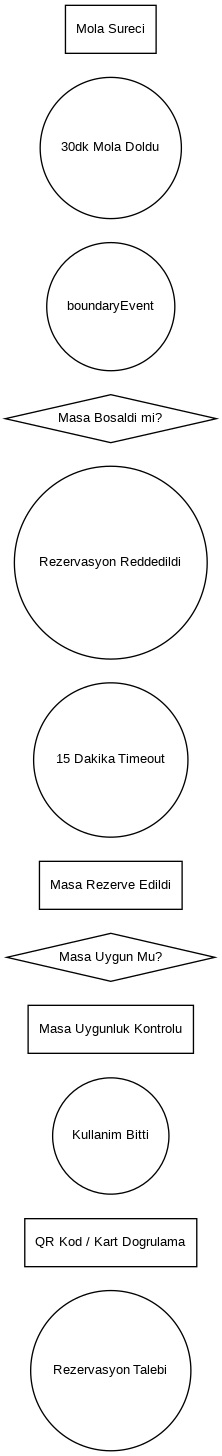

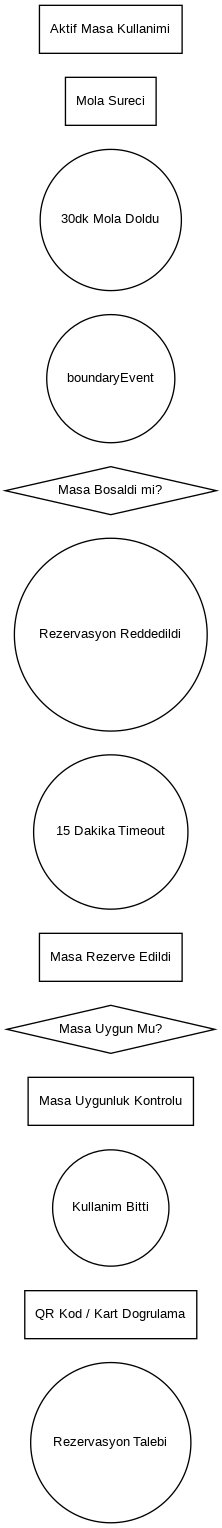

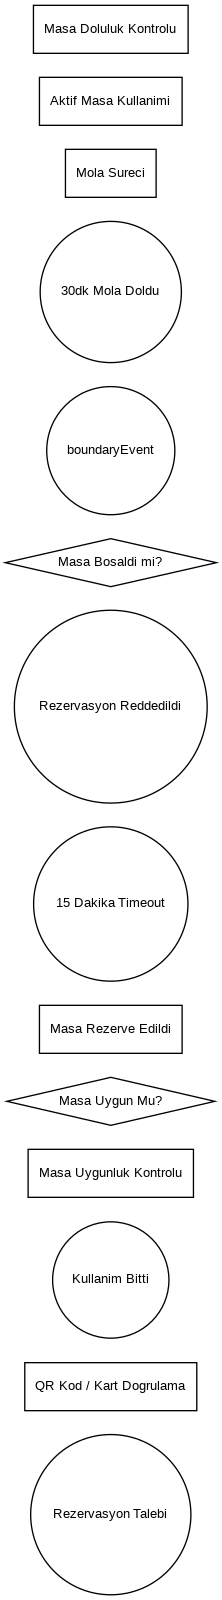

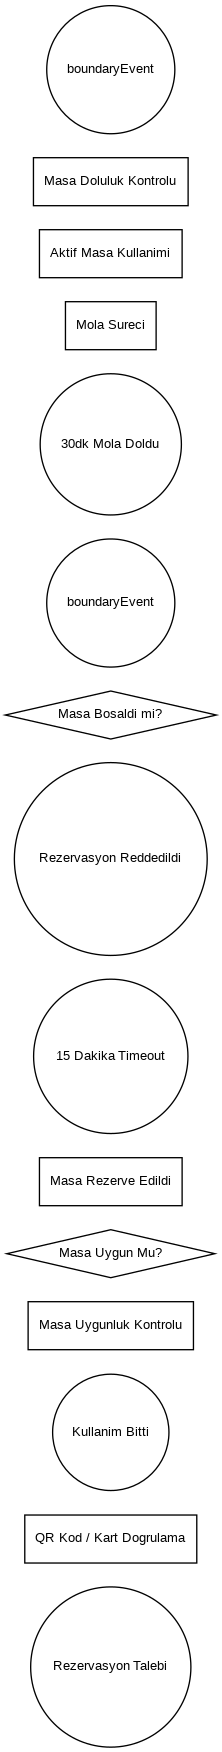

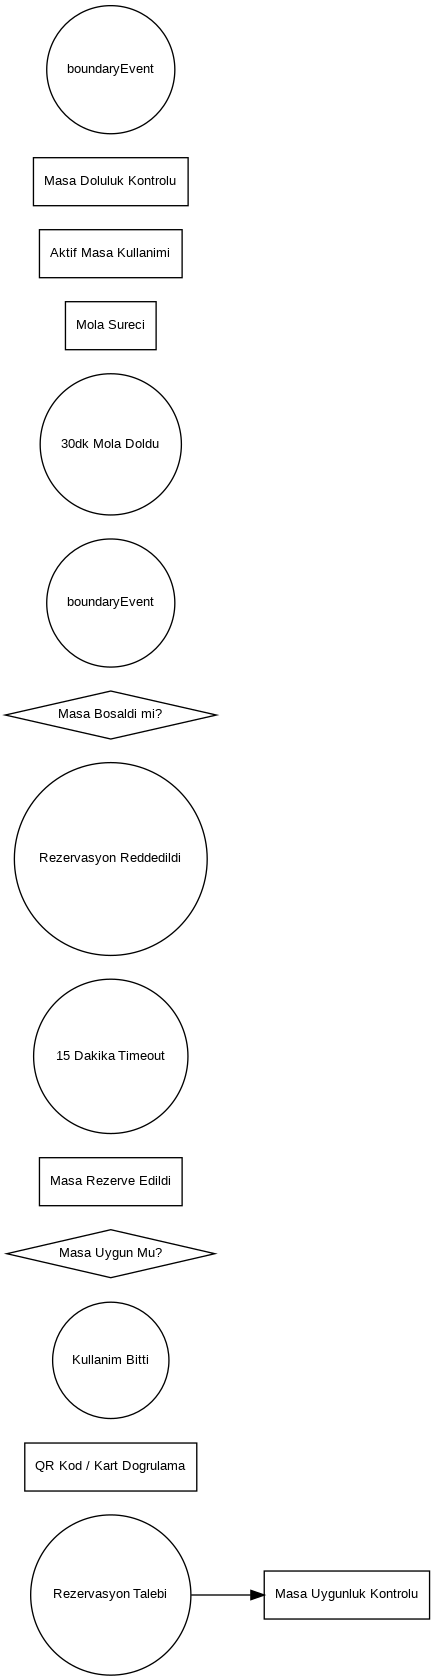

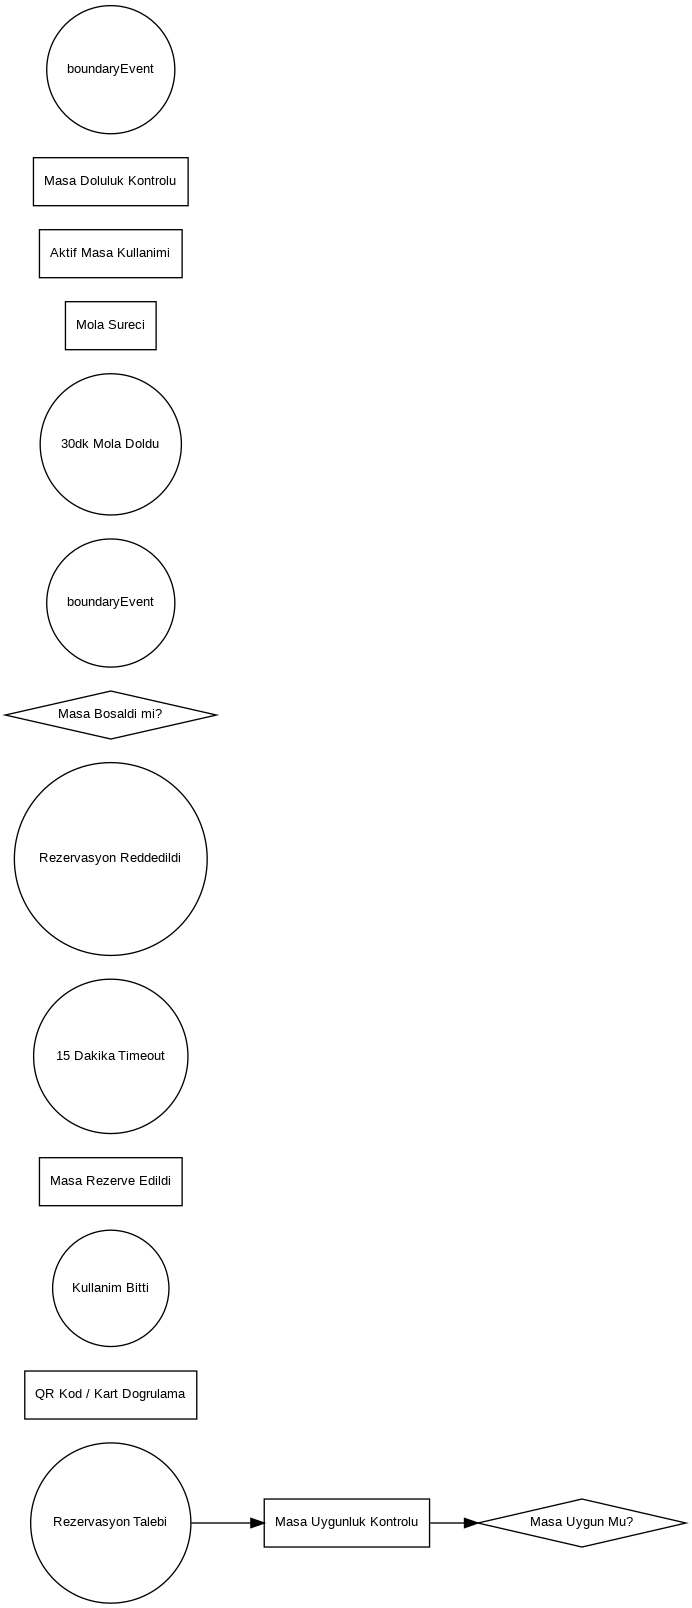

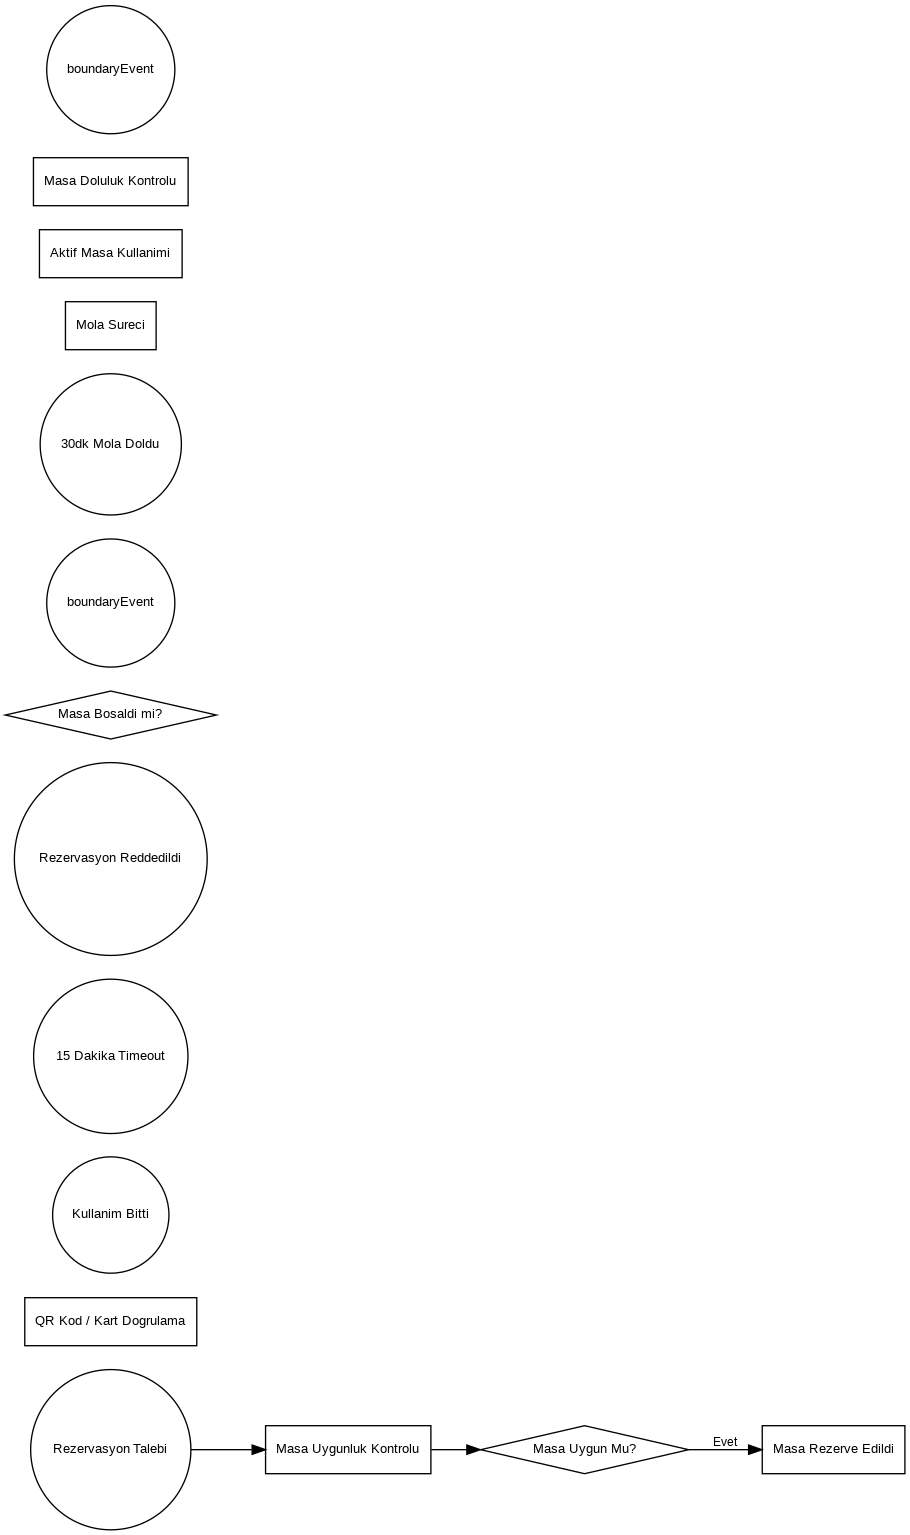

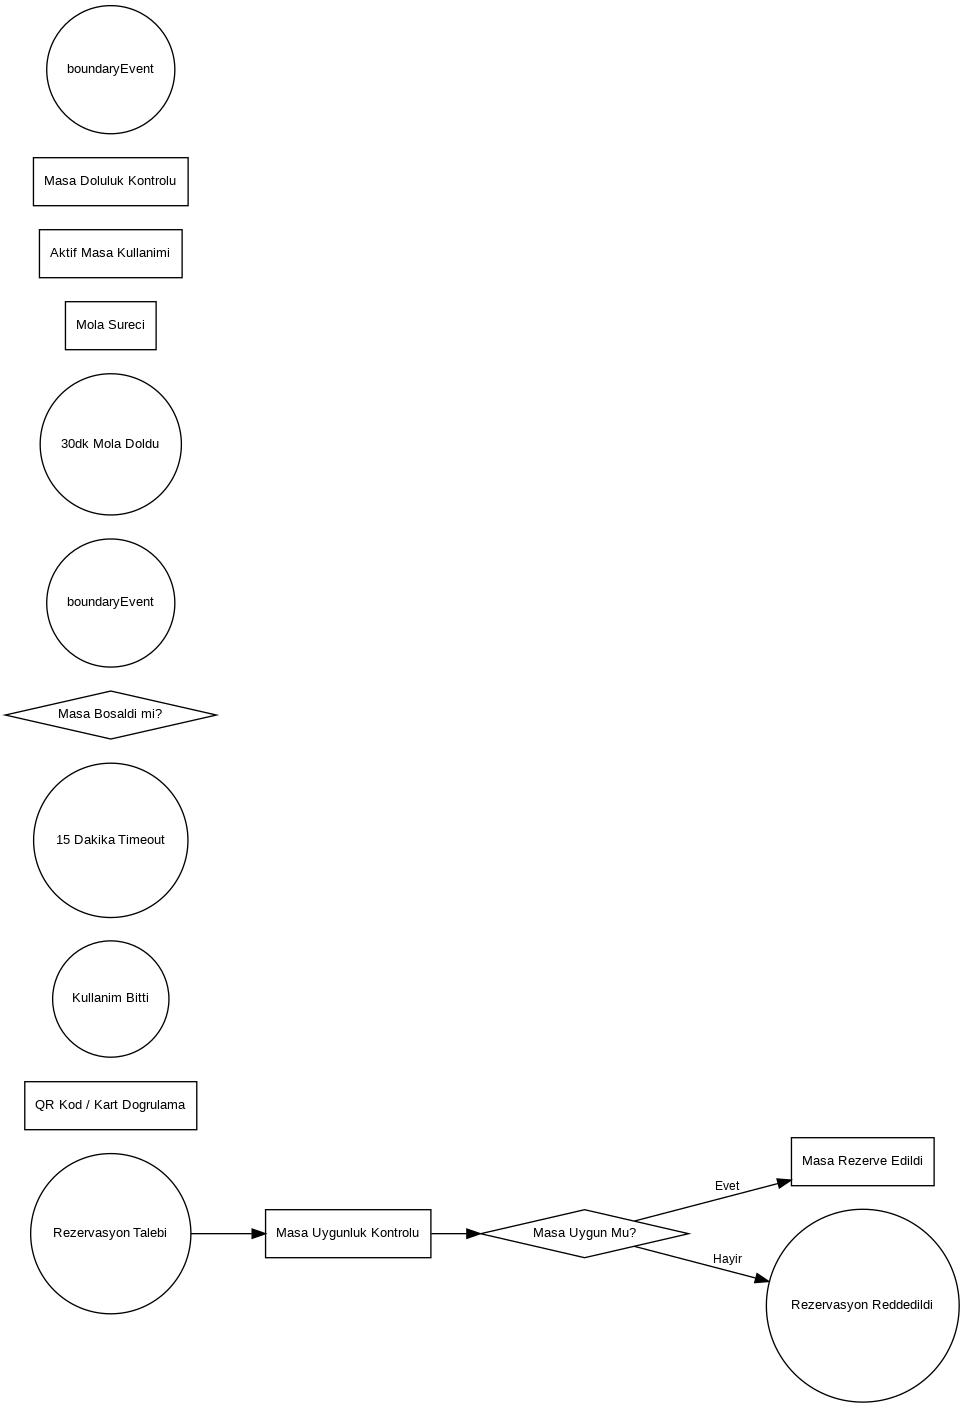

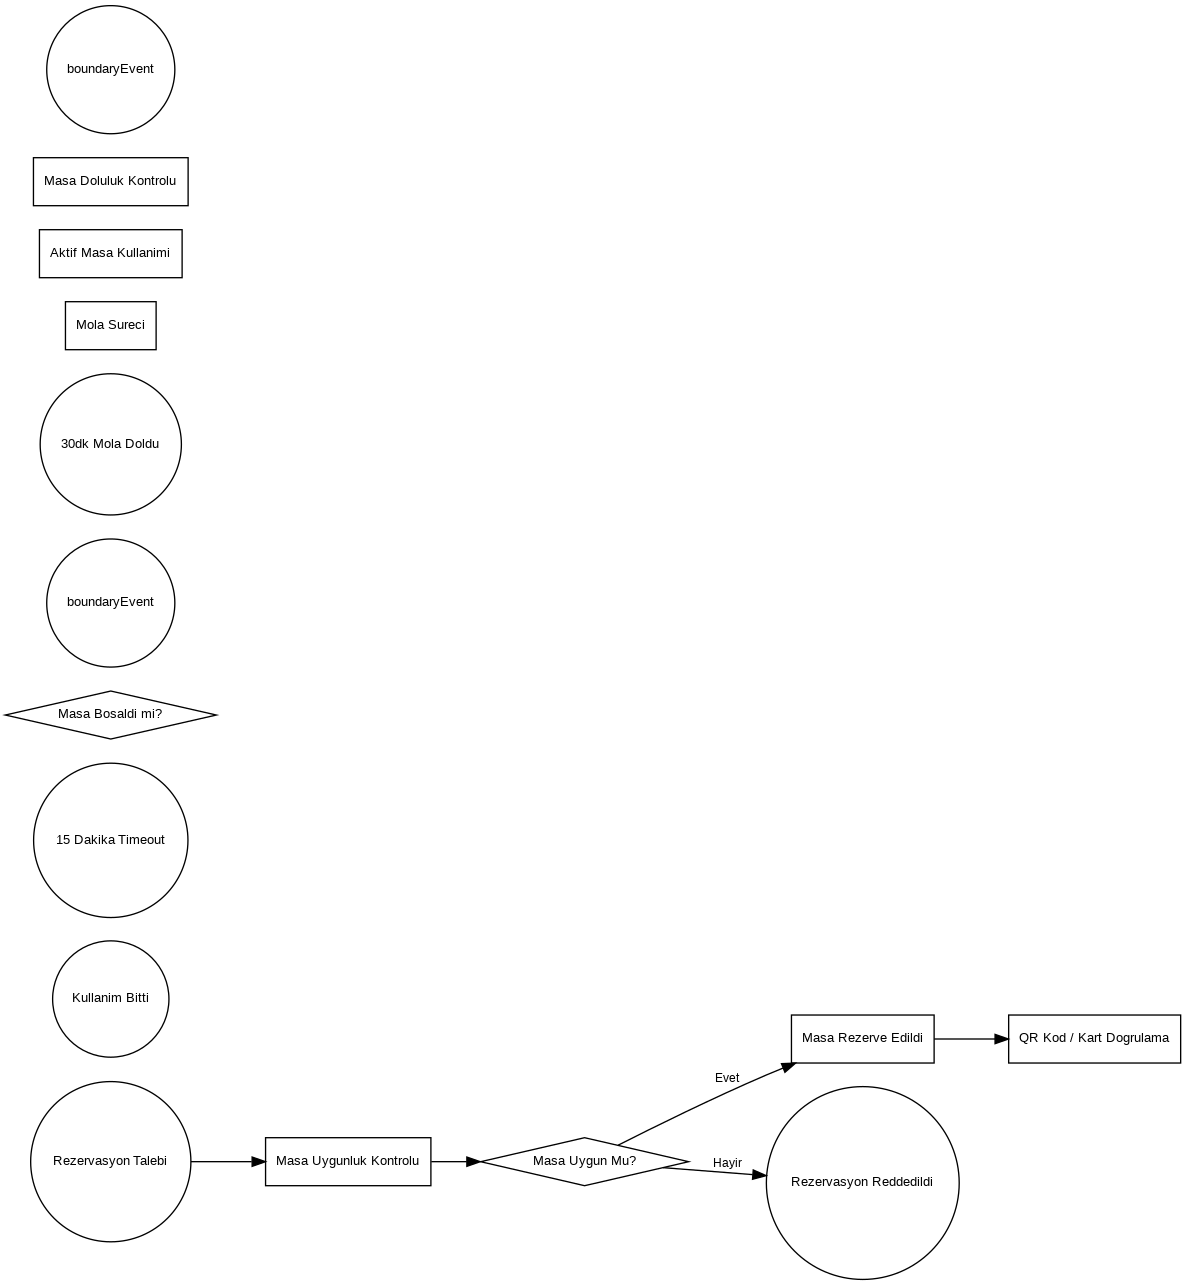

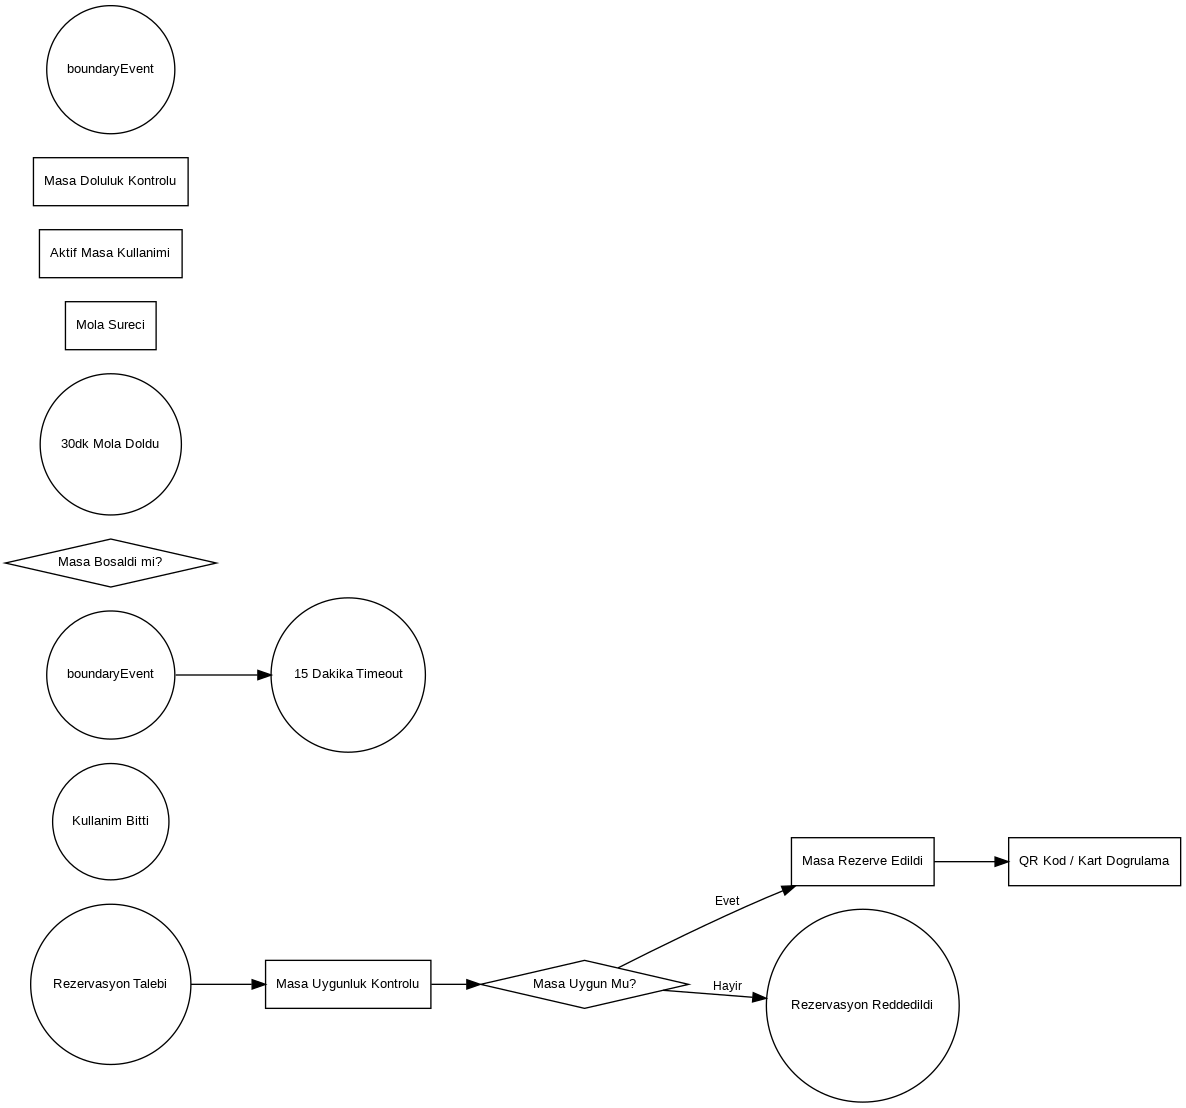

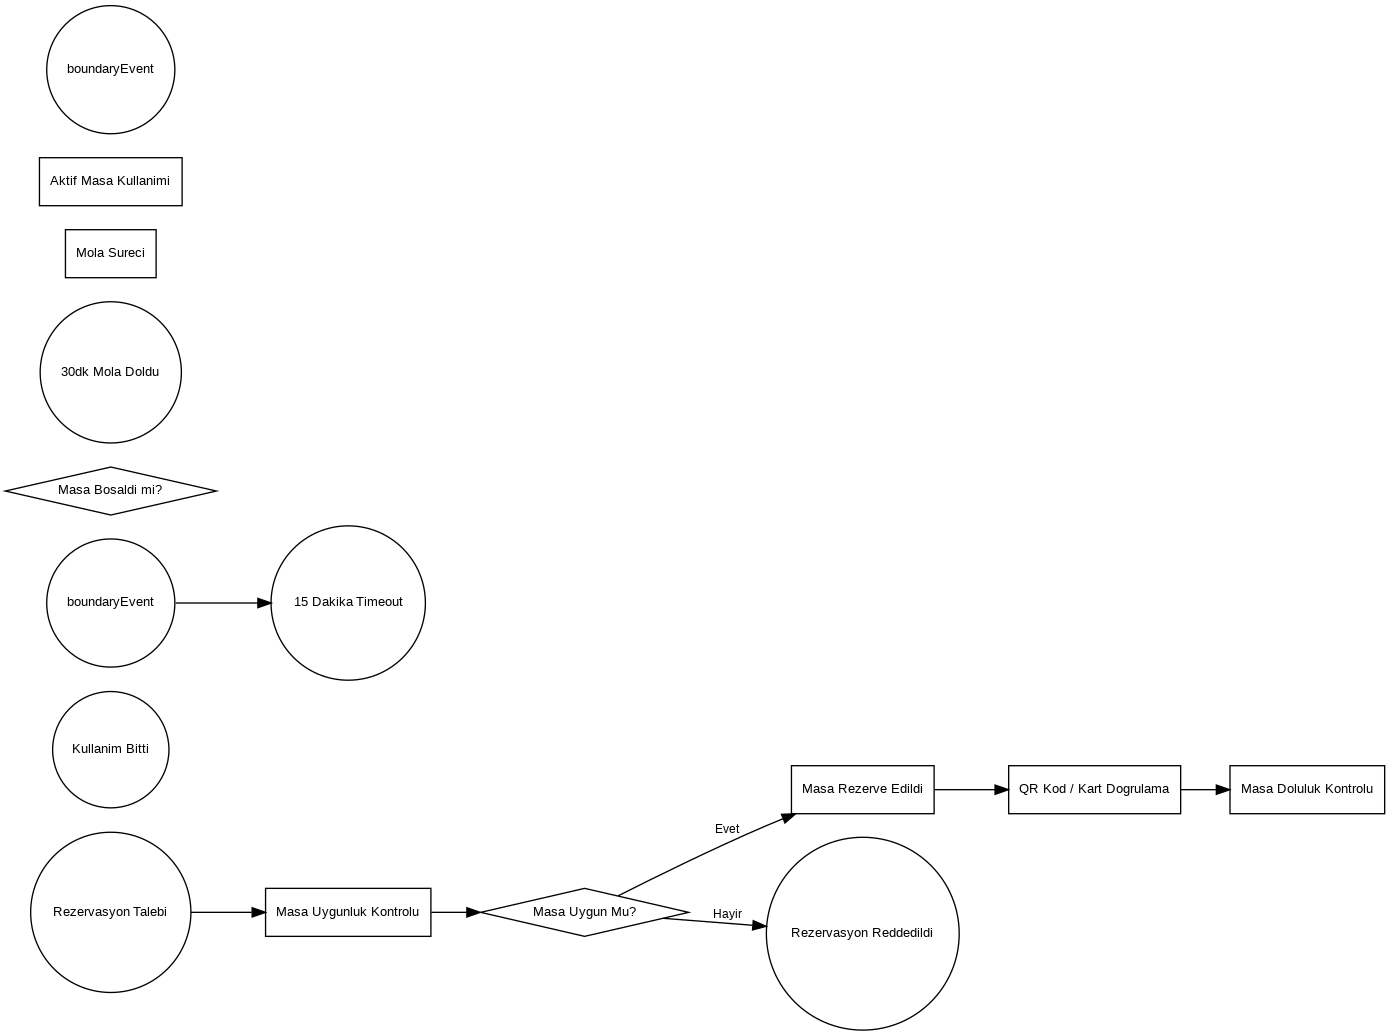

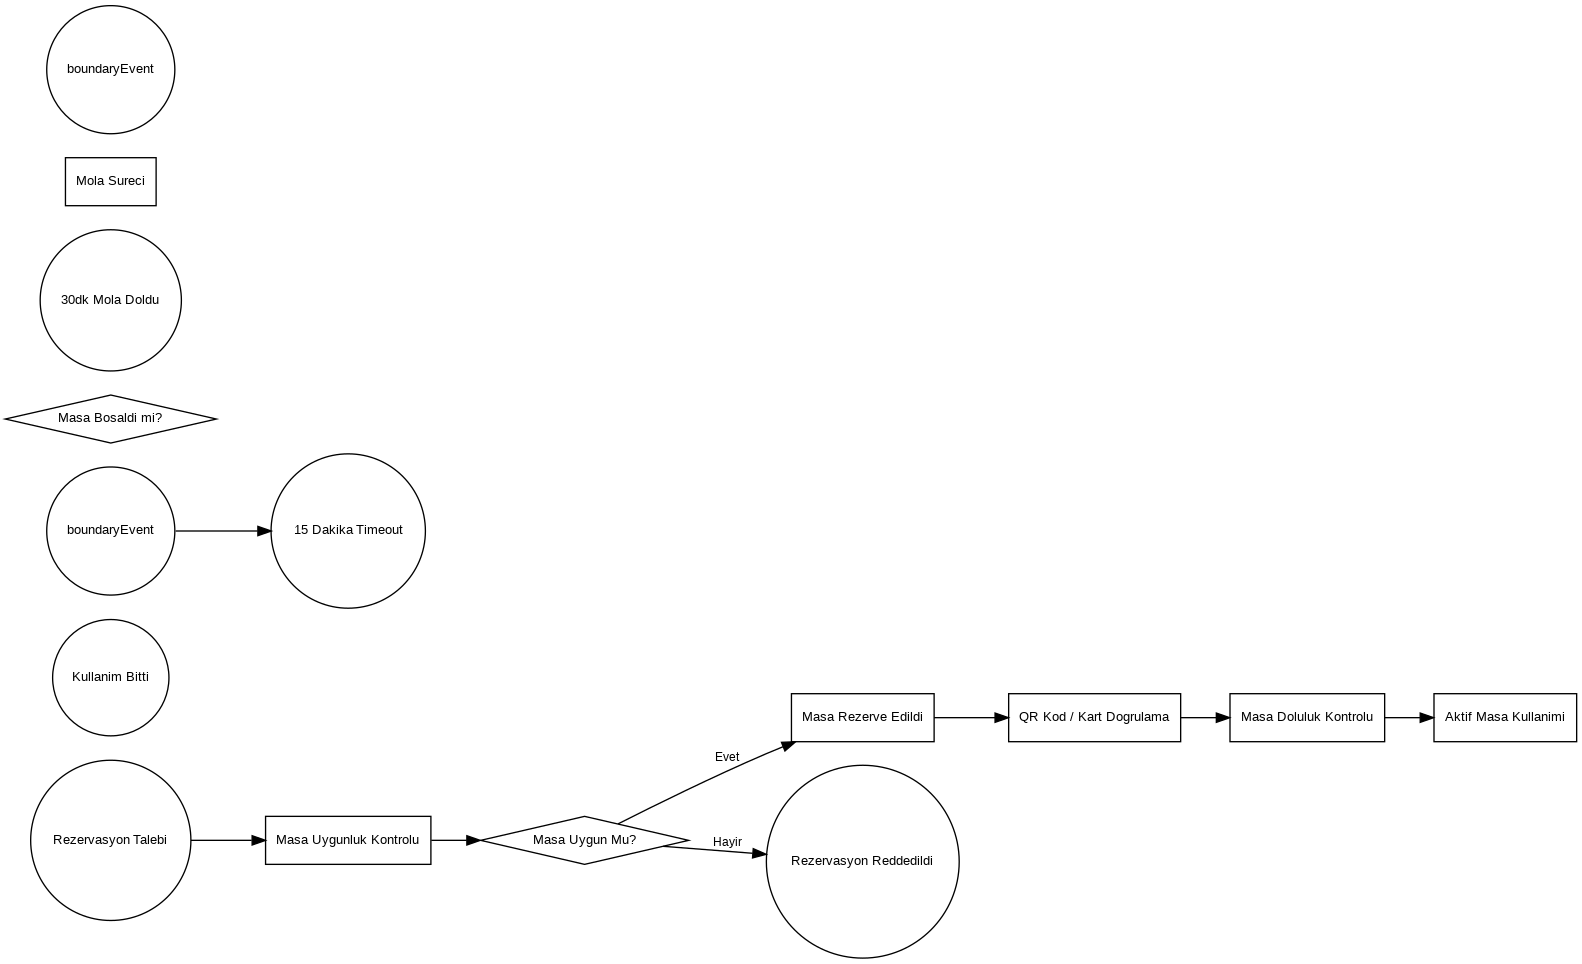

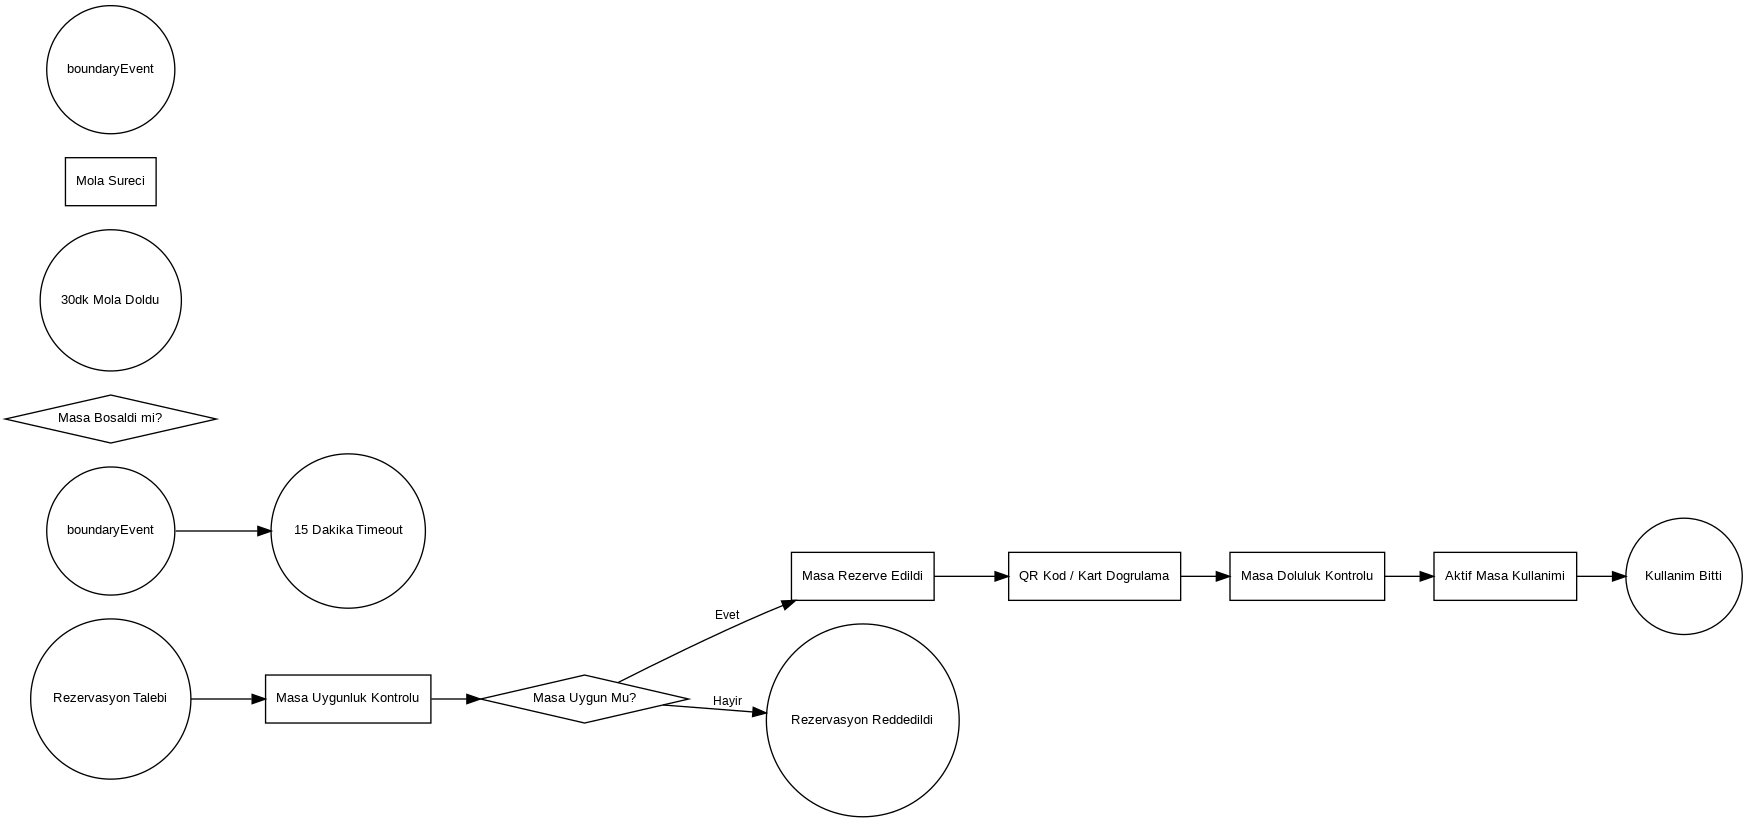

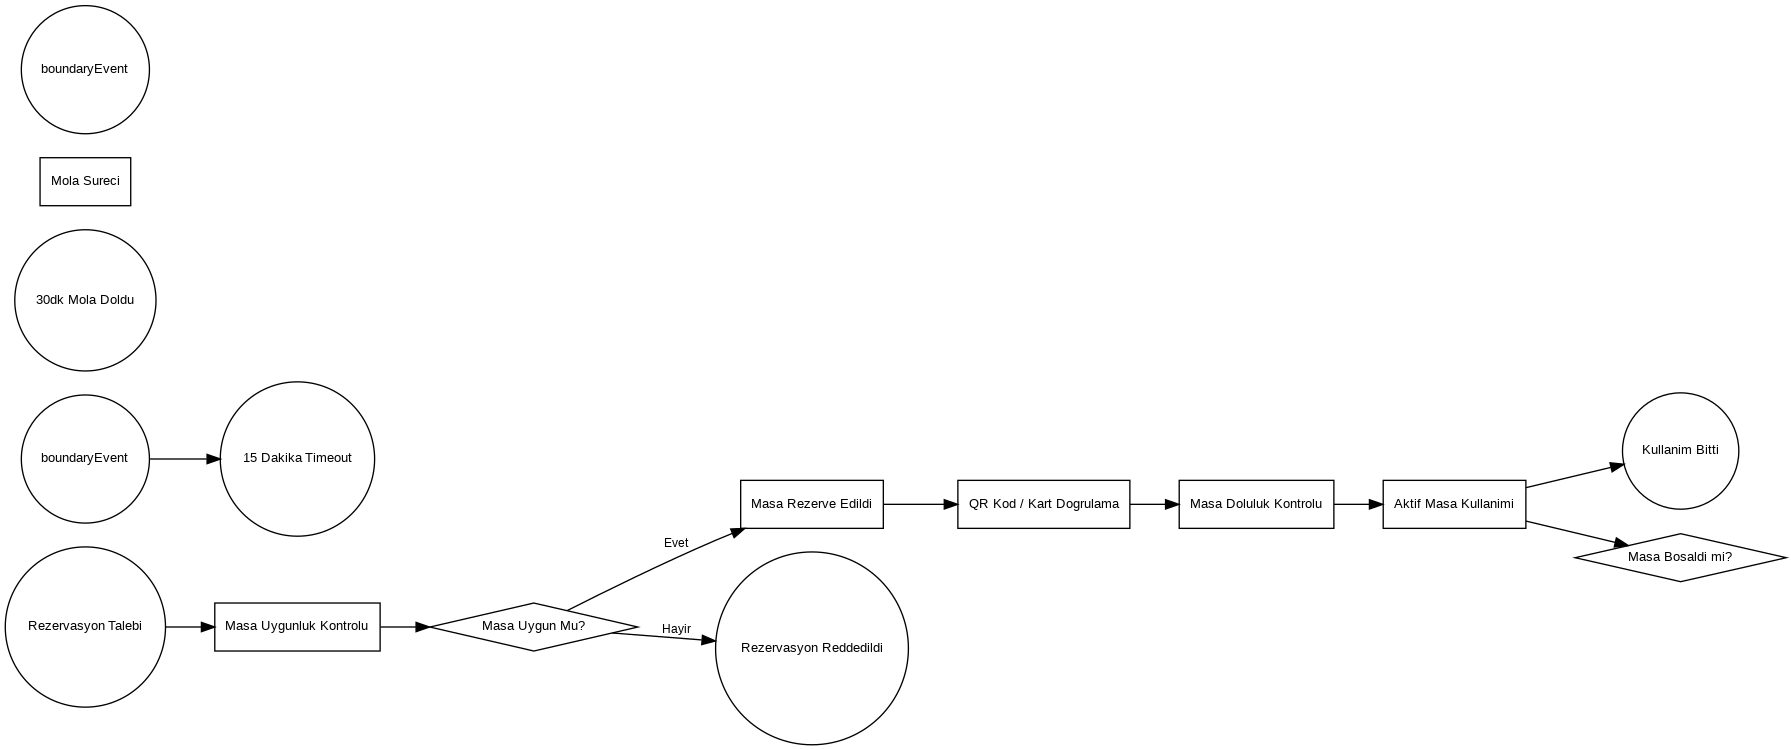

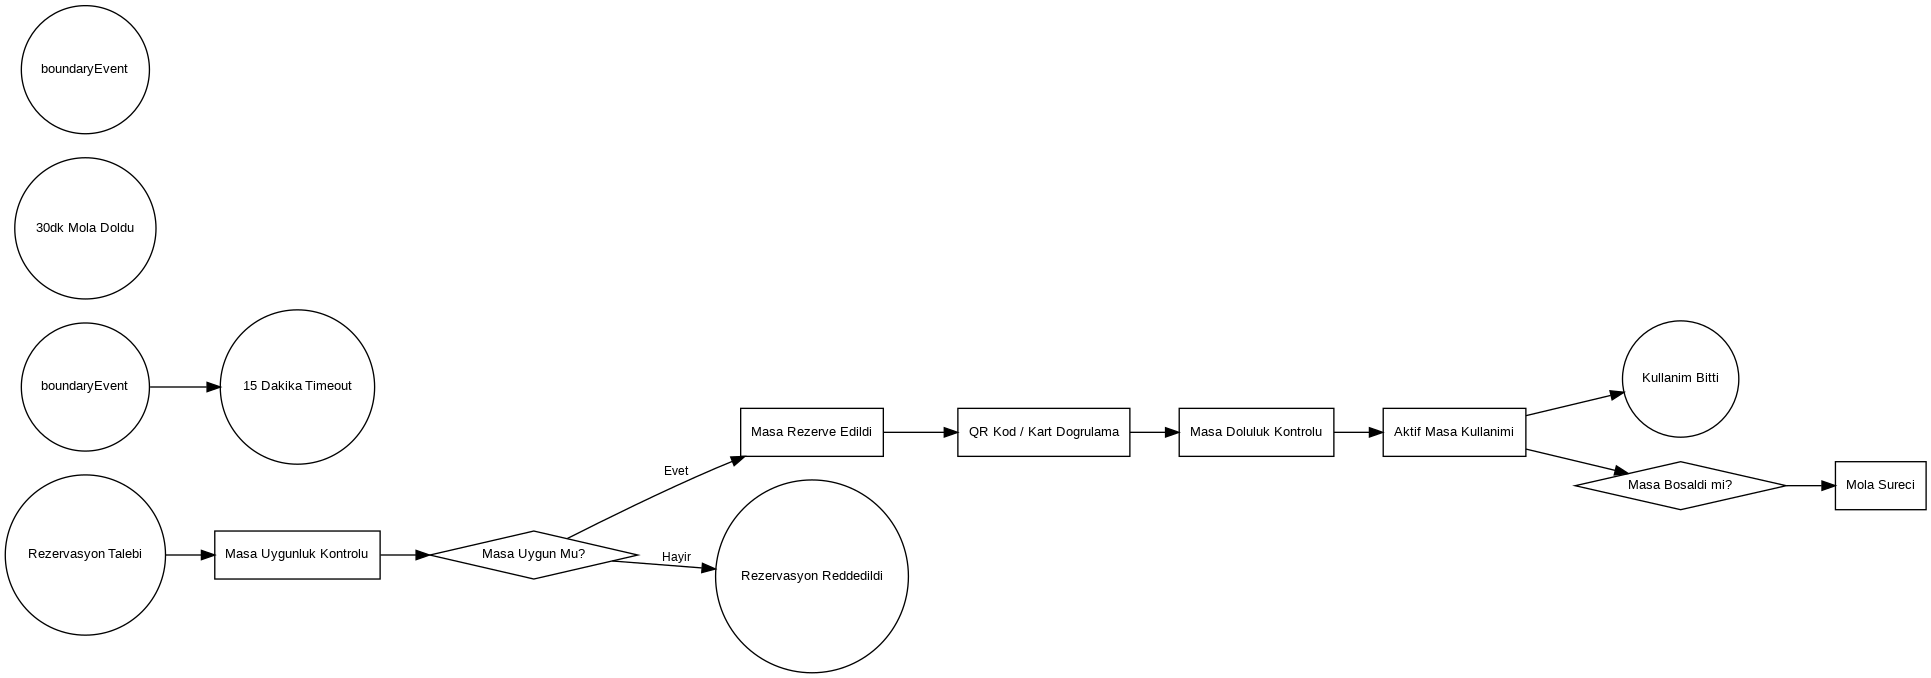

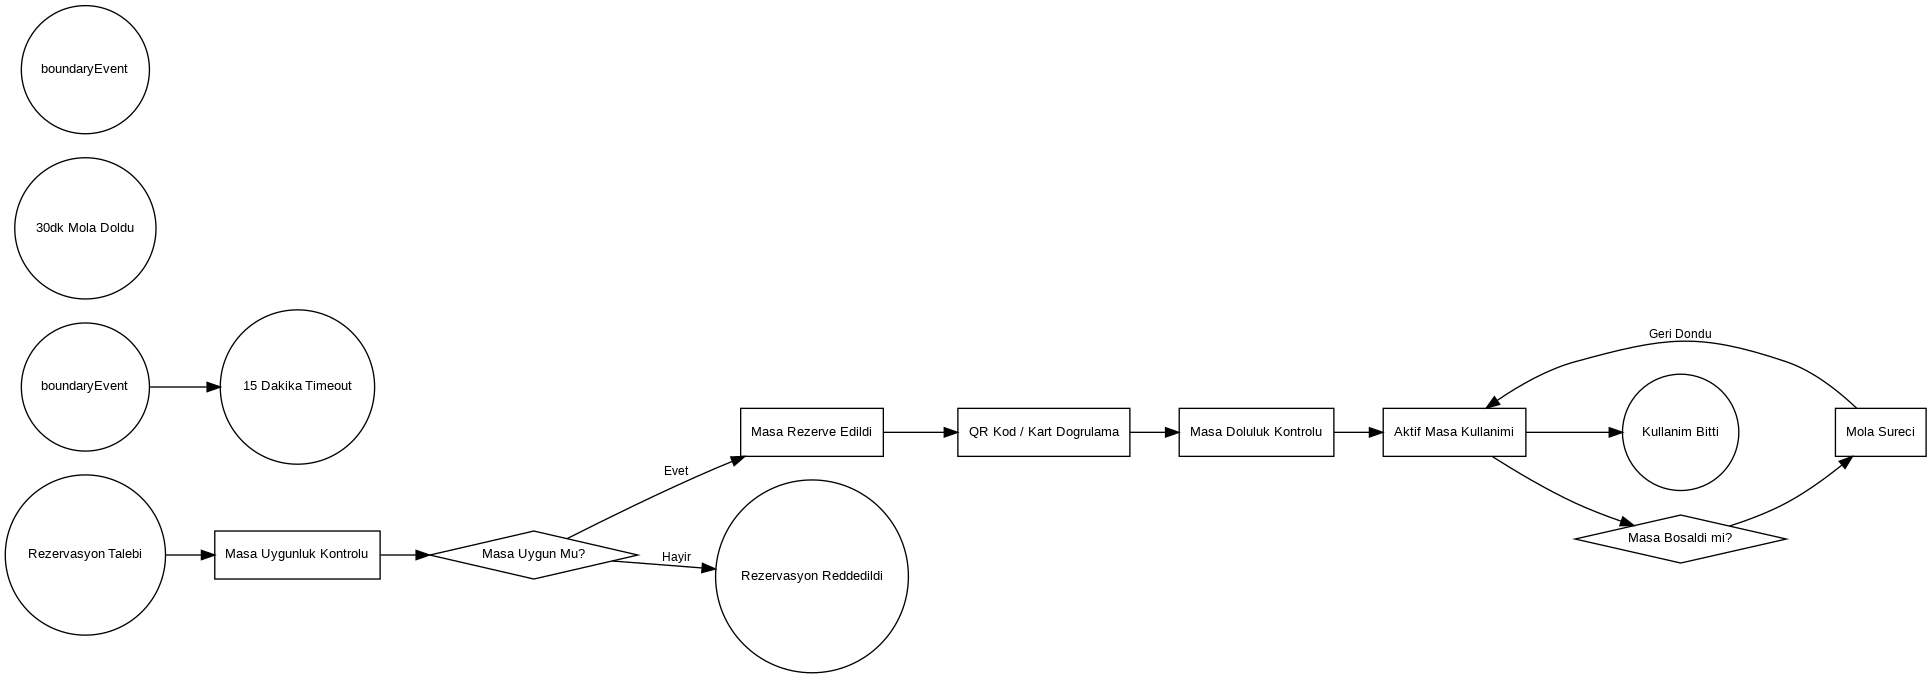

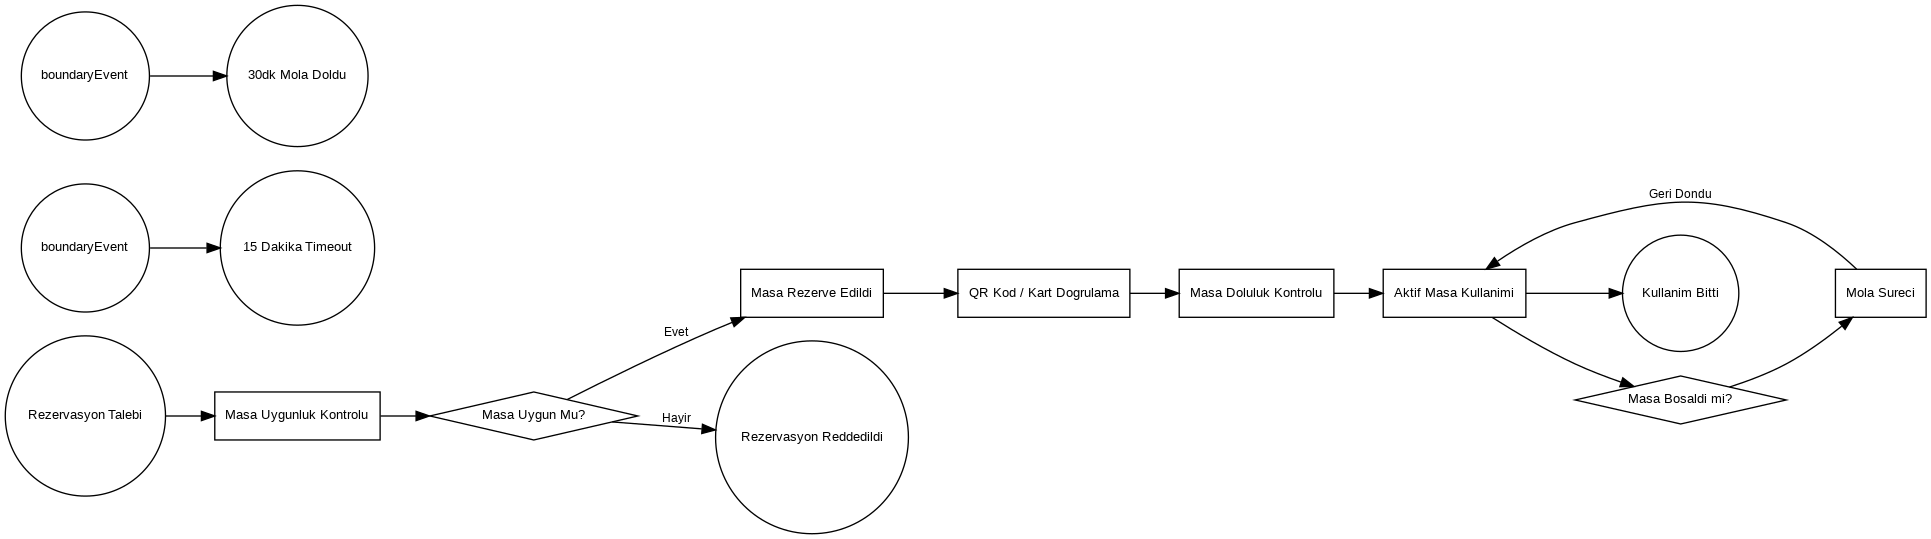

In [8]:
# -*- coding: utf-8 -*-

from graphviz import Digraph
import xml.etree.ElementTree as ET
from IPython.display import Image, display

xml_data = '''<?xml version="1.0" encoding="UTF-8"?>
<bpmn:definitions xmlns:bpmn="http://www.omg.org/spec/BPMN/20100524/MODEL"
                  id="Definitions_1" targetNamespace="http://bpmn.io/schema/bpmn">
  <bpmn:process id="Process_1q9scjh" isExecutable="true">
    <bpmn:laneSet id="LaneSet_0f42zsi">
      <bpmn:lane id="Lane_1fgm40a" name="Ogrenci">
        <bpmn:flowNodeRef>Event_158gjwh</bpmn:flowNodeRef>
        <bpmn:flowNodeRef>Activity_1k72f0j</bpmn:flowNodeRef>
        <bpmn:flowNodeRef>Event_15mx0nr</bpmn:flowNodeRef>
      </bpmn:lane>
      <bpmn:lane id="Lane_0cacvaf" name="Kutuphane Sistemi">
        <bpmn:flowNodeRef>Activity_08l0btw</bpmn:flowNodeRef>
        <bpmn:flowNodeRef>Gateway_16ux8lr</bpmn:flowNodeRef>
        <bpmn:flowNodeRef>Activity_00v1mih</bpmn:flowNodeRef>
        <bpmn:flowNodeRef>Event_067q9lt</bpmn:flowNodeRef>
        <bpmn:flowNodeRef>Event_0v57448</bpmn:flowNodeRef>
        <bpmn:flowNodeRef>Gateway_0ydnfg2</bpmn:flowNodeRef>
        <bpmn:flowNodeRef>Event_1bwaxj3</bpmn:flowNodeRef>
      </bpmn:lane>
      <bpmn:lane id="Lane_0ccldp6" name="IoT Sensorleri">
        <bpmn:flowNodeRef>Event_0lhwpwo</bpmn:flowNodeRef>
        <bpmn:flowNodeRef>Activity_0s486e9</bpmn:flowNodeRef>
        <bpmn:flowNodeRef>Activity_00760rv</bpmn:flowNodeRef>
        <bpmn:flowNodeRef>Activity_0qqfc91</bpmn:flowNodeRef>
        <bpmn:flowNodeRef>Event_0eocxa5</bpmn:flowNodeRef>
      </bpmn:lane>
    </bpmn:laneSet>
    <bpmn:startEvent id="Event_158gjwh" name="Rezervasyon Talebi"/>
    <bpmn:userTask id="Activity_1k72f0j" name="QR Kod / Kart Dogrulama"/>
    <bpmn:endEvent id="Event_15mx0nr" name="Kullanim Bitti"/>
    <bpmn:businessRuleTask id="Activity_08l0btw" name="Masa Uygunluk Kontrolu"/>
    <bpmn:exclusiveGateway id="Gateway_16ux8lr" name="Masa Uygun Mu?"/>
    <bpmn:task id="Activity_00v1mih" name="Masa Rezerve Edildi"/>
    <bpmn:endEvent id="Event_067q9lt" name="15 Dakika Timeout"/>
    <bpmn:endEvent id="Event_0v57448" name="Rezervasyon Reddedildi"/>
    <bpmn:exclusiveGateway id="Gateway_0ydnfg2" name="Masa Bosaldi mi?"/>
    <bpmn:boundaryEvent id="Event_1bwaxj3" attachedToRef="Activity_00v1mih"/>
    <bpmn:endEvent id="Event_0lhwpwo" name="30dk Mola Doldu"/>
    <bpmn:task id="Activity_0s486e9" name="Mola Sureci"/>
    <bpmn:task id="Activity_00760rv" name="Aktif Masa Kullanimi"/>
    <bpmn:serviceTask id="Activity_0qqfc91" name="Masa Doluluk Kontrolu"/>
    <bpmn:boundaryEvent id="Event_0eocxa5" attachedToRef="Activity_0s486e9"/>
    <bpmn:sequenceFlow id="Flow_1o6sy5a" sourceRef="Event_158gjwh"   targetRef="Activity_08l0btw"/>
    <bpmn:sequenceFlow id="Flow_0gelx02" sourceRef="Activity_08l0btw" targetRef="Gateway_16ux8lr"/>
    <bpmn:sequenceFlow id="Flow_0brhxwd" sourceRef="Gateway_16ux8lr"  targetRef="Activity_00v1mih">
      <bpmn:conditionExpression>Evet</bpmn:conditionExpression>
    </bpmn:sequenceFlow>
    <bpmn:sequenceFlow id="Flow_1hqfdrx" sourceRef="Gateway_16ux8lr"  targetRef="Event_0v57448">
      <bpmn:conditionExpression>Hayir</bpmn:conditionExpression>
    </bpmn:sequenceFlow>
    <bpmn:sequenceFlow id="Flow_1btsv74" sourceRef="Activity_00v1mih" targetRef="Activity_1k72f0j"/>
    <bpmn:sequenceFlow id="Flow_1wzxo7d" sourceRef="Event_1bwaxj3"   targetRef="Event_067q9lt"/>
    <bpmn:sequenceFlow id="Flow_0ad899u" sourceRef="Activity_1k72f0j" targetRef="Activity_0qqfc91"/>
    <bpmn:sequenceFlow id="Flow_1sascu3" sourceRef="Activity_0qqfc91" targetRef="Activity_00760rv"/>
    <bpmn:sequenceFlow id="Flow_1cox3fu" sourceRef="Activity_00760rv" targetRef="Event_15mx0nr"/>
    <bpmn:sequenceFlow id="Flow_071an22" sourceRef="Activity_00760rv" targetRef="Gateway_0ydnfg2"/>
    <bpmn:sequenceFlow id="Flow_1m676l4" sourceRef="Gateway_0ydnfg2"  targetRef="Activity_0s486e9"/>
    <bpmn:sequenceFlow id="Flow_0wxxp3v" sourceRef="Activity_0s486e9" targetRef="Activity_00760rv">
      <bpmn:conditionExpression>Geri Dondu</bpmn:conditionExpression>
    </bpmn:sequenceFlow>
    <bpmn:sequenceFlow id="Flow_0gbqs4x" sourceRef="Event_0eocxa5"   targetRef="Event_0lhwpwo"/>
  </bpmn:process>
</bpmn:definitions>'''

# XML parse et
root = ET.fromstring(xml_data)

# Namespace
ns = {'bpmn': 'http://www.omg.org/spec/BPMN/20100524/MODEL'}

dot = Digraph(comment='Akilli Kutuphane BPMN')
dot.attr(rankdir='LR', fontname='Helvetica')
dot.node_attr.update(fontname='Helvetica', fontsize='10')
dot.edge_attr.update(fontname='Helvetica', fontsize='9')

# Node'ları adım adım ekle ve göster
for process in root.findall('.//bpmn:process', ns):
    for elem in process:
        tag = elem.tag.split('}')[-1]
        if tag in ['startEvent', 'endEvent', 'task', 'userTask',
                   'serviceTask', 'businessRuleTask', 'exclusiveGateway', 'boundaryEvent']:
            node_id = elem.attrib['id']
            label = elem.attrib.get('name', tag)
            if 'Event' in tag:
                shape = 'circle'
            elif tag == 'exclusiveGateway':
                shape = 'diamond'
            else:
                shape = 'box'
            dot.node(node_id, label, shape=shape)
            display(Image(dot.render(format='png', view=False)))

    # Okları adım adım ekle ve göster
    for flow in process.findall('bpmn:sequenceFlow', ns):
        source = flow.attrib['sourceRef']
        target = flow.attrib['targetRef']
        label = ''
        for child in flow:
            if child.tag.endswith('conditionExpression'):
                label = child.text
        dot.edge(source, target, label)
        display(Image(dot.render(format='png', view=False)))